In [6]:
import pandas as pd
df = pd.read_csv("advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [8]:
X_cont = df.iloc[:,0:4]

In [9]:
# stndardization
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(X_cont)
SS_X = pd.DataFrame(SS_X)
SS_X.columns = list(X_cont)
SS_X.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage
0,0.249267,-0.114905,0.509691,1.734030
1,0.961132,-0.570425,1.002530,0.313805
2,0.282083,-1.139826,0.356949,1.287589
3,0.577432,-0.798185,-0.014456,1.501580
4,0.212664,-0.114905,1.408868,1.038731


In [10]:
df['Male']

,Male
0,0
1,1
2,0
3,1
4,0
...,...
995,1
996,1
997,1
998,0


In [11]:
X = pd.concat([SS_X,df['Male']],axis=1)
X.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
0,0.249267,-0.114905,0.509691,1.734030,0
1,0.961132,-0.570425,1.002530,0.313805,1
2,0.282083,-1.139826,0.356949,1.287589,0
3,0.577432,-0.798185,-0.014456,1.501580,1
4,0.212664,-0.114905,1.408868,1.038731,0


In [12]:
Y = df["Clicked on Ad"]

In [23]:
# trianing the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X,Y)

df["Y_pred"] = model.predict(X)
df["Y_pred_proba"] = model.predict_proba(X)[::,1]

In [14]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Y_pred
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0,0


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(Y,df["Y_pred"])
print(cm)

score = accuracy_score(Y,df["Y_pred"])
print("Accuracy score: ", np.round(score,2))

[[491   9]
 [ 21 479]]
Accuracy score:  0.97


In [16]:
from sklearn.metrics import recall_score, precision_score, f1_score

recall = recall_score(Y,df["Y_pred"])
print("Sensitivity score:", np.round(recall,2))

Specificity = recall_score(df["Y_pred"],Y)
print("Specificity score:", np.round(Specificity,2))

Precision = precision_score(Y,df["Y_pred"])
print("Precision score:", np.round(Precision,2))

f1s = f1_score(Y,df["Y_pred"])
print("F1 score:", np.round(f1s,2))

Sensitivity score: 0.96
Specificity score: 0.98
Precision score: 0.98
F1 score: 0.97


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

In [22]:
TPR, FPR, dummy = roc_curve(Y,df["Y_pred_proba"])

AUC score: 0.99


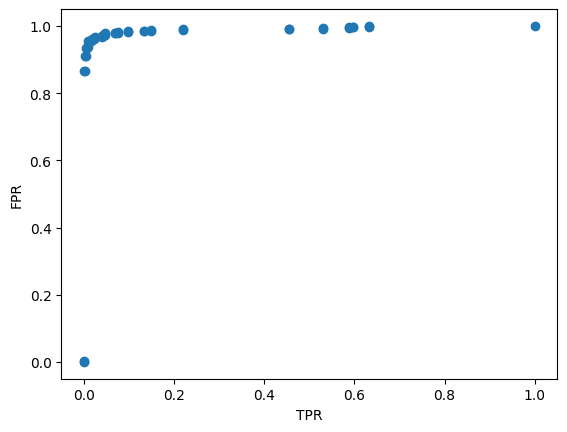

In [26]:
auc_score = roc_auc_score(Y,df["Y_pred_proba"])
print("AUC score:", np.round(auc_score,2))

import matplotlib.pyplot as plt
plt.scatter(TPR,FPR)
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.show()